## Task 1: Multi-Chart Visualization Notebook [Medium] 
Using any real dataset (e.g, Titanic, Iris, or your ETL dataset), create a jupyter notebook with at least 6 chart types: 
bar, line, histogram, scatter, box plot, and heatmap. Each chart must have a proper title, axis labels with units, and a 1-sentence insight caption beneath it.

Use matplotlib for at least 4 and seaborn for at least 2.

### Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Optional styling
plt.style.use("ggplot")

### Load Dataset

In [9]:
df = pd.read_csv(r"..\..\week_4(ETL_Data_Cleaning)\Task_8\tvmaze_cleaned.csv")

df.head()

,id,url,name,type,language,genres,status,premiered,ended,summary,rating_average,schedule_time,schedule_days,premier_year,rating_category,summary_word_count,show_duration_years
0,1,https://www.tvmaze.com/shows/1/under-the-dome,Under the Dome,Scripted,English,"['Drama', 'Science-Fiction', 'Thriller']",Ended,2013-06-24,2015-09-10,Under the Dome is the story of a small town th...,6.6,22:00,Thursday,2013,Good,57,2.0
1,2,https://www.tvmaze.com/shows/2/person-of-interest,Person of Interest,Scripted,English,"['Action', 'Crime', 'Science-Fiction']",Ended,2011-09-22,2016-06-21,You are being watched. The government has a se...,8.8,22:00,Tuesday,2011,Excellent,96,5.0
2,3,https://www.tvmaze.com/shows/3/bitten,Bitten,Scripted,English,"['Drama', 'Horror', 'Romance']",Ended,2014-01-11,2016-04-15,Based on the critically acclaimed series of no...,7.4,22:00,Friday,2014,Good,75,2.0
3,4,https://www.tvmaze.com/shows/4/arrow,Arrow,Scripted,English,"['Drama', 'Action', 'Science-Fiction']",Ended,2012-10-10,2020-01-28,"After a violent shipwreck, billionaire playboy...",7.4,21:00,Tuesday,2012,Good,85,8.0
4,5,https://www.tvmaze.com/shows/5/true-detective,True Detective,Scripted,English,"['Drama', 'Crime', 'Thriller']",Running,2014-01-12,NaN,Touch darkness and darkness touches you back. ...,8.1,21:00,Sunday,2014,Excellent,47,12.0


### Basic Cleaning

In [12]:
# =========================
# BASIC CLEANING
# =========================

# Check dataset info
print(df.info())

# Check missing values
print(df.isnull().sum())

# Remove rows where rating is missing
df = df.dropna(subset=["rating_average"])

# Convert date columns to datetime
df["premiered"] = pd.to_datetime(df["premiered"], errors="coerce")
df["ended"] = pd.to_datetime(df["ended"], errors="coerce")

# Remove duplicate rows if any
df = df.drop_duplicates()

# Clean text columns
df["name"] = df["name"].str.strip()
df["language"] = df["language"].str.strip()
df["type"] = df["type"].str.strip()

# Ensure numerical columns are proper numeric types
numeric_cols = [
    "rating_average",
    "premier_year",
    "summary_word_count",
    "show_duration_years"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Remove rows with invalid years
df = df[df["premier_year"] > 1900]

# Final shape after cleaning
print("Cleaned Dataset Shape:", df.shape)


<class 'pandas.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   id                   240 non-null    int64         
 1   url                  240 non-null    str           
 2   name                 240 non-null    str           
 3   type                 240 non-null    str           
 4   language             240 non-null    str           
 5   genres               240 non-null    str           
 6   status               240 non-null    str           
 7   premiered            240 non-null    datetime64[us]
 8   ended                219 non-null    datetime64[us]
 9   summary              240 non-null    str           
 10  rating_average       240 non-null    float64       
 11  schedule_time        225 non-null    str           
 12  schedule_days        235 non-null    str           
 13  premier_year         240 non-null    int64    

### Bar Chart (Matplotlib)
Average Rating by Show Type

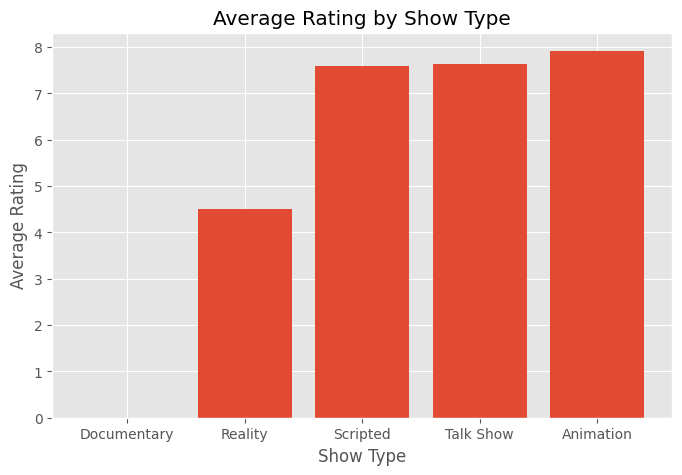

In [13]:
avg_rating = df.groupby("type")["rating_average"].mean().sort_values()

plt.figure(figsize=(8,5))
plt.bar(avg_rating.index, avg_rating.values)

plt.title("Average Rating by Show Type")
plt.xlabel("Show Type")
plt.ylabel("Average Rating")

plt.show()

### Line Chart (Matplotlib)
Number of Shows Premiered Each Year

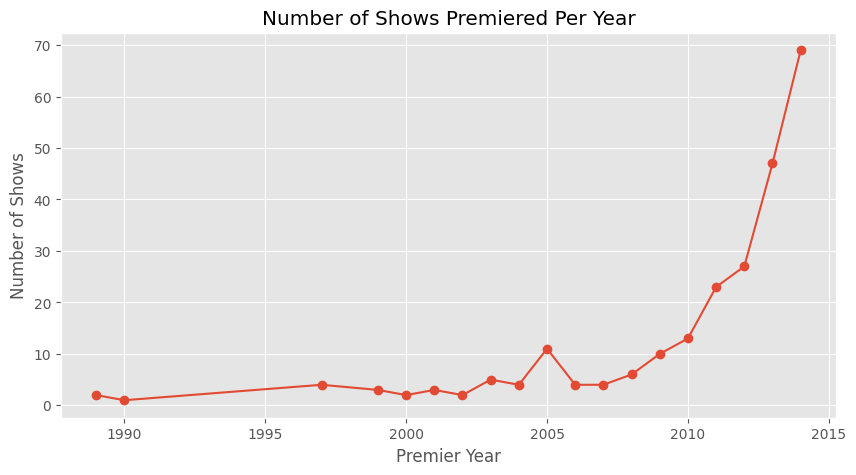

In [14]:
shows_per_year = df["premier_year"].value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.plot(shows_per_year.index, shows_per_year.values, marker='o')

plt.title("Number of Shows Premiered Per Year")
plt.xlabel("Premier Year")
plt.ylabel("Number of Shows")

plt.show()

### Histogram (Matplotlib)
Distribution of Ratings

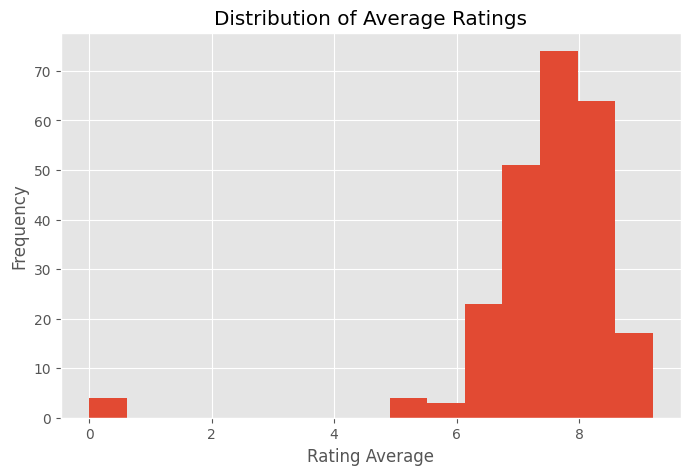

In [15]:
plt.figure(figsize=(8,5))
plt.hist(df["rating_average"], bins=15)

plt.title("Distribution of Average Ratings")
plt.xlabel("Rating Average")
plt.ylabel("Frequency")

plt.show()

### Scatter Plot (Matplotlib)
Summary Word Count vs Rating

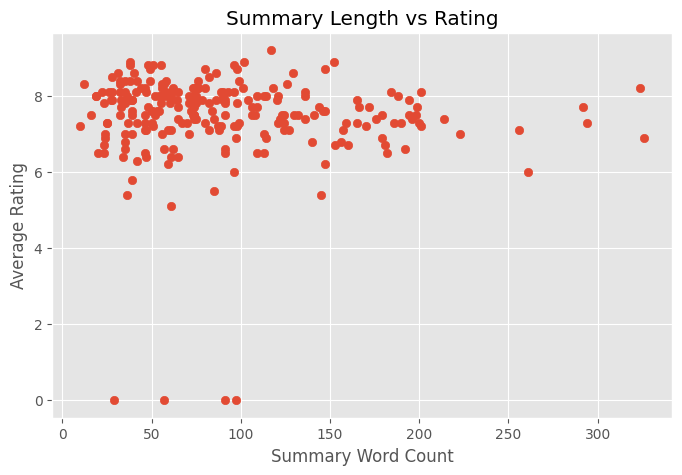

In [16]:
plt.figure(figsize=(8,5))
plt.scatter(
    df["summary_word_count"],
    df["rating_average"]
)

plt.title("Summary Length vs Rating")
plt.xlabel("Summary Word Count")
plt.ylabel("Average Rating")

plt.show()

### Box Plot (Seaborn)
Rating Distribution by Rating Category

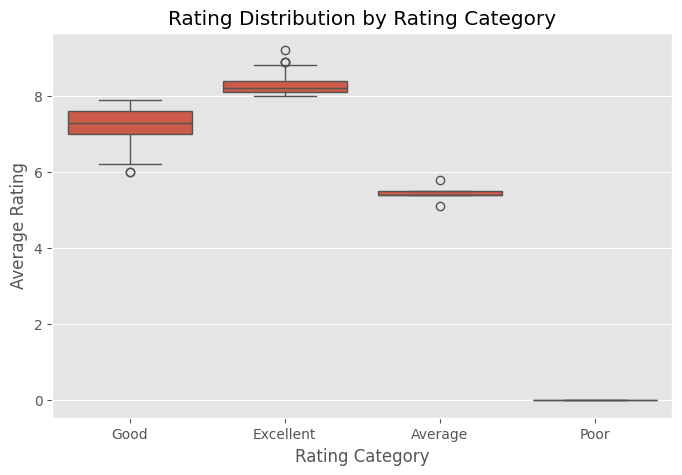

In [17]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="rating_category",
    y="rating_average"
)

plt.title("Rating Distribution by Rating Category")
plt.xlabel("Rating Category")
plt.ylabel("Average Rating")

plt.show()

### Heatmap (Seaborn)
Correlation Heatmap

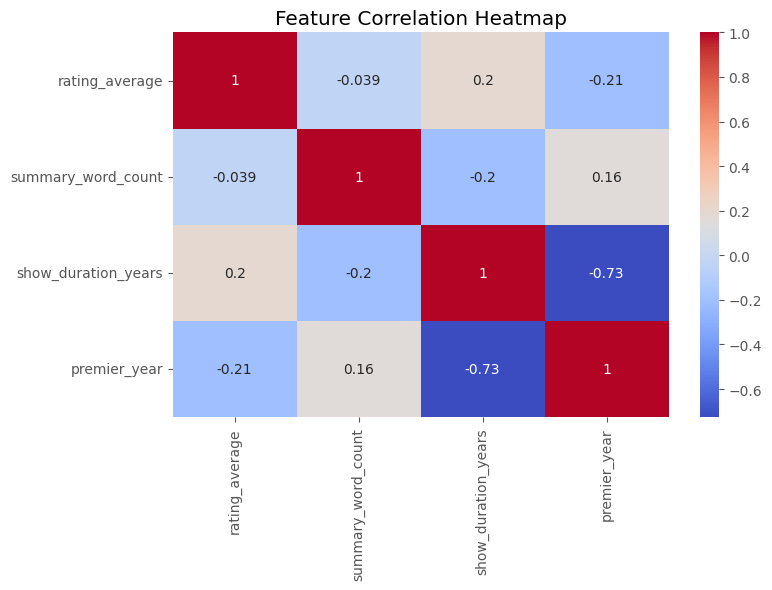

In [18]:
numeric_cols = df[
    ["rating_average",
     "summary_word_count",
     "show_duration_years",
     "premier_year"]
]

correlation = numeric_cols.corr()

plt.figure(figsize=(8,5))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")

plt.show()